In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams['figure.dpi'] = 72
import numpy as np

import torch
import torchaudio
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

Device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

print(f'PyTorch version= {torch.__version__}')
print(f'torchaudio version= {torchaudio.__version__}')
print(f'CUDA available= {torch.cuda.is_available()}')

PyTorch version= 2.10.0
torchaudio version= 2.10.0
CUDA available= False


In [2]:
# notes
Note_Freqs = {
 'C2': 65.41, 'C#2': 69.3, 'D2': 73.42, 'D#2': 77.78, 'E2': 82.41, 'F2': 87.31,
 'F#2': 92.5, 'G2': 98.0, 'G#2': 103.83, 'A2': 110.0, 'A#2': 116.54, 'B2': 123.47,
 'C3': 130.81, 'C#3': 138.59, 'D3': 146.83, 'D#3': 155.56, 'E3': 164.81, 'F3': 174.61,
 'F#3': 185.0, 'G3': 196.0, 'G#3': 207.65, 'A3': 220.0, 'A#3': 233.08, 'B3': 246.94,
 'C4': 261.63, 'C#4': 277.18, 'D4': 293.66, 'D#4': 311.13, 'E4': 329.63, 'F4': 349.23,
 'F#4': 369.99, 'G4': 392.0, 'G#4': 415.3, 'A4': 440.0, 'A#4': 466.16, 'B4': 493.88,
 'C5': 523.25, 'C#5': 554.37, 'D5': 587.33, 'D#5': 622.25, 'E5': 659.25, 'F5': 698.46,
 'F#5': 739.99, 'G5': 783.99, 'G#5': 830.61, 'A5': 880.0, 'A#5': 932.33, 'B5': 987.77,
 'C6': 1046.5, 'C#6': 1108.73, 'D6': 1174.66, 'D#6': 1244.51, 'E6': 1318.51, 'F6': 1396.91,
 'F#6': 1479.98, 'G6': 1567.98, 'G#6': 1661.22, 'A6': 1760.0, 'A#6': 1864.66, 'B6': 1975.53,
 'C7': 2093.0, 'C#7': 2217.46, 'D7': 2349.32, 'D#7': 2489.02, 'E7': 2637.02, 'F7': 2793.83,
 'F#7': 2959.96, 'G7': 3135.96, 'G#7': 3322.44, 'A7': 3520.0, 'A#7': 3729.31, 'B7': 3951.07
}
Notes = list(Note_Freqs.keys())  # labels - notes
SEQ_LEN= 50

# generate sinewaves for notes using the frequency in Note_Freqs
class NoteDataset(Dataset):
    def __init__(self, n_samples=512, seq_len=SEQ_LEN):
        self.data, self.labels = [], []
        for _ in range(n_samples):
            note = np.random.choice(Notes)  # randomly generate signals
            f = Note_Freqs[note]
            x = np.arange(seq_len)
            sine_wave = np.sin(2 * np.pi * f * x / 10000)  # sample at 10kHz
            self.data.append(torch.tensor(sine_wave, dtype=torch.float32))
            self.labels.append(Notes.index(note))  # encode note as index, like ID of a token

        self.data = torch.stack(self.data)
        self.labels = torch.tensor(self.labels, dtype=torch.long)  # labels, IDs are torch.long 

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        return self.data[idx], self.labels[idx]

class TransformerNotePredictor(nn.Module):
    def __init__(self, input_dim=1, model_dim=16, nhead=2, n_encoder_layers=1, n_classes=len(Notes)):
        super().__init__()
        self.embedding = nn.Linear(input_dim, model_dim)
        self.pos_encoding = nn.Parameter(torch.rand(SEQ_LEN, model_dim))  # trainable positional encoding
        self.transformer = nn.Transformer(model_dim, nhead, n_encoder_layers, num_decoder_layers=0, batch_first=True)
        self.classifier = nn.Linear(model_dim, n_classes)  # output layer

    def forward(self, _x):
        # add positional encoding
        _x = self.embedding(_x.unsqueeze(-1)) + self.pos_encoding  # shape: (batch, seq_len, model_dim)
        _x = _x.permute(1, 0, 2)  # Transformer expects (seq_len, batch, model_dim)
        _x = self.transformer.encoder(_x)
        _x = _x.mean(dim=0)  # average over seq len
        return self.classifier(_x)  # logits for classification

def train(_model, _dataloader, epochs=10, lr=0.001, info=False):
    import sys
    optimizer = optim.Adam(_model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()

    for e in range(epochs):
        totloss = 0
        for x, y in _dataloader:
            optimizer.zero_grad()
            out = _model(x)
            loss = criterion(out, y)
            loss.backward()
            optimizer.step()
            totloss += loss.item()
        
        if info:
            sys.stderr.write(f"\r{e+1:3d}/{epochs:3d} | Loss: {totloss:3.3f}")
            sys.stderr.flush()


# generation function, given a sine wave predict the note
def predict(_model, _wav):
    _model.eval()
    with torch.no_grad():
        out = _model(_wav.unsqueeze(0))  # add batch dimension
        pred_note = Notes[out.argmax(dim=1).item()]
    return pred_note

# dataset
ds_notes = NoteDataset(n_samples=1024)  # there will be repeats
Dloader = DataLoader(ds_notes, batch_size=32, shuffle=False)

In [3]:
ds_notes[0][0]

tensor([ 0.0000,  0.1160,  0.2304,  0.3417,  0.4484,  0.5490,  0.6423,  0.7268,
         0.8016,  0.8655,  0.9178,  0.9576,  0.9846,  0.9982,  0.9984,  0.9851,
         0.9585,  0.9190,  0.8671,  0.8034,  0.7290,  0.6447,  0.5516,  0.4512,
         0.3446,  0.2334,  0.1191,  0.0031, -0.1129, -0.2273, -0.3387, -0.4456,
        -0.5464, -0.6398, -0.7247, -0.7997, -0.8639, -0.9165, -0.9567, -0.9840,
        -0.9980, -0.9986, -0.9856, -0.9594, -0.9202, -0.8686, -0.8053, -0.7311,
        -0.6471, -0.5543])

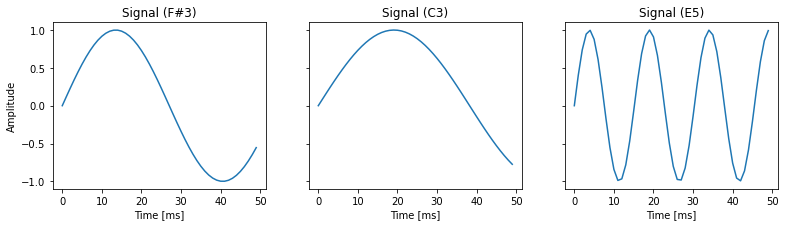

In [4]:
# plot some signals
fig, ax = plt.subplots(1, 3, figsize=(13,3), sharey=True, dpi=72)
ax[0].plot(ds_notes[0][0])
ax[1].plot(ds_notes[1][0])
ax[2].plot(ds_notes[2][0])
ax[0].set(xlabel='Time [ms]', ylabel='Amplitude', title=f'Signal ({Notes[ds_notes[0][1]]})')
ax[1].set(xlabel='Time [ms]', title=f'Signal ({Notes[ds_notes[1][1]]})')
ax[2].set(xlabel='Time [ms]', title=f'Signal ({Notes[ds_notes[2][1]]})')
plt.show()

In [5]:
Model = TransformerNotePredictor()

In [6]:
%%time

train(Model, Dloader, epochs=100, info=True)

100/100 | Loss: 10.5818

CPU times: user 3min 34s, sys: 30.4 s, total: 4min 4s
Wall time: 1min 46s


In [7]:
# evaluation
print(f"Pred   Orig")
for _ in np.random.randint(0, len(ds_notes), size=20):
    d, t = ds_notes[_]
    pred = predict(Model, d)
    print(f"{pred:<4s}   {Notes[t]:<4s}")

Pred   Orig
C6     C6  
F#4    F#4 
D7     D7  
C7     C7  
A#3    A#3 
G7     G7  
D3     D3  
A2     G#2 
C#3    C#3 
D3     D3  
B7     B7  
D3     D3  
G6     G6  
C3     C3  
C3     B2  
C6     C6  
F6     F6  
E5     E5  
G#7    G#7 
F#7    F#7 
